In [40]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
import pickle

In [16]:
df = pd.read_csv('dataset/demand_forecasting.csv')

In [17]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [18]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [19]:
target = "Demand"

In [20]:
x = df[features].copy()

In [21]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [22]:
y = df[target]

In [23]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [24]:
label_encoders = {}

categorical_cols = x.select_dtypes(include="object").columns

In [25]:
categorical_cols

Index(['Category'], dtype='str')

In [26]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le


In [27]:
label_encoders

{'Category': LabelEncoder()}

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

In [30]:
xgb = XGBRegressor(object = "reg:squarederror", n_jobs = -1)

In [31]:
param_dict = {
    "n_estimators": [200, 300, 500],
    "max_length" : [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [32]:
random_search = RandomizedSearchCV(
    estimator = xgb, 
    param_distributions= param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1

)

In [33]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_length': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategi

In [34]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_length': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [35]:
best_model = random_search.best_estimator_

In [36]:
y_pred = best_model.predict(x_test)

In [45]:
mean_squared_error(y_test, y_pred)

1288.04443359375

In [46]:
best_model.feature_importances_

array([0.09052452, 0.02815787, 0.02193394, 0.59075433, 0.03093369,
       0.23769566], dtype=float32)

In [47]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending = False)

In [53]:
feature_importance.round(2)

Promotion             0.59
Category              0.24
Price                 0.09
Competitor Pricing    0.03
Discount              0.03
Inventory Level       0.02
dtype: float32

<Axes: >

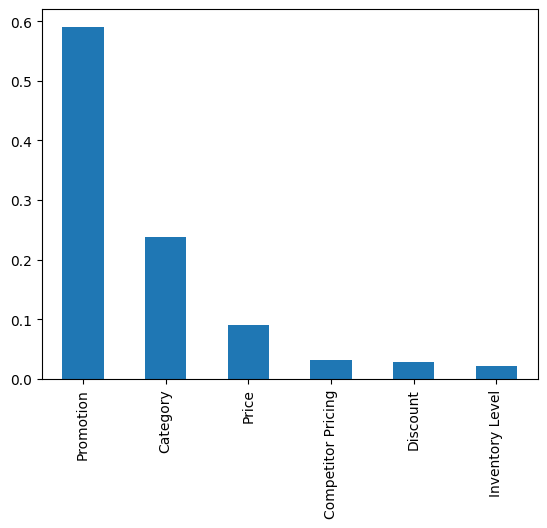

In [54]:
feature_importance.plot(kind='bar')

In [55]:
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders,f)

In [56]:
with open('models/xgboost_demand_model.pkl', 'wb') as f:
    pickle.dump(best_model,f)